# 7장 어떤 나라가 교역을 많이 할까

이 장에서는 **어떤 나라가 대외 교역을 더 많이 하는지** 데이터를 통해 살펴본다. 교역의 정도는 총수출입액을 GDP로 나눈 대외개방도(무역의존도)로 평가하고, 이것이 1인당 GDP, 인구수, 내륙국 여부, 원격성 정도 등과 어떤 관련성이 있는지 분석한다.

## 1. 데이터

출처: UNCTAD (2012), [*A Practical Guide to Trade Policy Analysis*](https://unctad.org/topic/trade-analysis/trade-policy-analysis)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 데이터 읽기
df = pd.read_stata("../Data/openness.dta")
df

,ccode,year,openc,openk,pop,gdp_current,ldlock,island,remoteness,remoteness_head
0,AGO,1976,77.27,74.60,5943.470215,NaN,0,0,6524.200684,3.317617e+10
1,AGO,1977,78.57,74.69,6163.709961,NaN,0,0,4004.112793,3.550263e+10
2,AGO,1978,77.27,73.42,6287.180176,NaN,0,0,6895.426270,4.819266e+10
3,AGO,1979,78.33,72.36,6452.549805,NaN,0,0,4345.329102,4.415073e+10
4,AGO,1980,70.37,68.90,6743.080078,NaN,0,0,4385.381348,4.752221e+10
...,...,...,...,...,...,...,...,...,...,...
3156,ZWE,2000,65.63,135.64,11820.000000,7.200000e+09,1,0,6461.141602,3.041992e+10
3157,ZWE,2001,34.14,137.42,11867.799805,9.060000e+09,1,0,5923.156250,4.171810e+10
3158,ZWE,2002,14.66,145.74,11866.000000,1.780000e+10,1,0,5923.958008,3.254959e+10
3159,ZWE,2003,4.83,137.79,11815.500000,NaN,1,0,5018.277832,4.569241e+10


In [2]:
df['year'].unique()

array([1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986,
       1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997,
       1998, 1999, 2000, 2001, 2002, 2003, 2004], dtype=int16)

**변수**

- `ccode` : 나라 코드  
- `year` : 연도  
- `openc` : 명목(경상) 금액 기준 대외개방도(%)
- `openk` : 실질 금액 기준 대외개방도(%)
- `pop` : 인구(천 명)
- `gdp_current` : 명목 GDP(미국 달러)
- `ldlock` : 내륙국(landlocked) 더미변수(1이면 내륙국)  
- `island` : 섬 여부 더미변수(1이면 섬)  
- `remoteness` : 주요 경제권으로부터의 원격성(떨어진 정도)
- `remoteness_head` : Keith Head의 정의에 따른 원격성

**대외개방도(무역의존도)**

- 어떤 나라 $i$의 총수출을 $X_i$, 총수입을 $M_i$, GDP를 $Y_i$라 할 때, 대외개방도는 $O_i = \frac{X_i + M_i}{Y_i}$이다.

**패널 데이터**

- 위 데이터세트는 각국의 대외개방도, GDP 등을 1976년부터 2004년까지 기록한 패널 데이터이다.

**1인당 GDP 변수 생성**

In [3]:
df['gdppc'] = df['gdp_current'] / (df['pop']*1000)

**변수명 변경**

In [4]:
df['hremot'] = df['remoteness_head']

## 2. 탐색적 분석

### 요약 통계량

- 연도 상관없이 모든 관측을 합쳐서(즉 pooling하여) 통계를 구해보자.
- 아래 결과를 보면, 명목 금액 기준 대외개방도(`openc`)는 평균 약 70%이다.
- 관측 나라 중 내륙국(`ldlock=1`)은 17.4%이고, 섬나라(`island=1`)는 14.7%라는 것을 알 수 있다.

In [5]:
df.describe()

,year,openc,openk,pop,gdp_current,ldlock,island,remoteness,remoteness_head,gdppc,hremot
count,3161.000000,3148.000000,3148.000000,3.161000e+03,3.039000e+03,3161.000000,3161.000000,3161.000000,3.161000e+03,3039.000000,3.161000e+03
mean,1990.000000,69.557440,67.794209,4.294793e+04,1.896310e+11,0.174312,0.146789,4597.614746,4.249648e+10,5350.563128,4.249648e+10
std,8.367924,47.232249,48.249086,1.378143e+05,7.569068e+11,0.379438,0.353951,1498.954346,1.009918e+10,8422.140083,1.009918e+10
min,1976.000000,4.830000,8.780000,1.616300e+02,1.110000e+08,0.000000,0.000000,1763.281738,2.657153e+10,66.856431,2.657153e+10
25%,1983.000000,42.702500,38.377500,4.140100e+03,3.510000e+09,0.000000,0.000000,3505.653320,3.436699e+10,414.386787,3.436699e+10
50%,1990.000000,58.175000,55.535000,9.868200e+03,1.460000e+10,0.000000,0.000000,4372.600098,4.088491e+10,1303.312123,4.088491e+10
75%,1997.000000,82.917500,81.182500,3.018410e+04,9.230000e+10,0.000000,0.000000,5539.866211,4.897284e+10,5675.060483,4.897284e+10
max,2004.000000,428.440000,426.720000,1.300000e+06,1.170000e+13,1.000000,1.000000,10993.935547,9.718070e+10,54650.064006,9.718070e+10


**상관계수**

In [6]:
# 선택한 변수들에 대한 상관계수 행렬 계산
selected_variables = df[['openc', 'gdppc', 'hremot']]
selected_variables.corr()

,openc,gdppc,hremot
openc,1.000000,0.142755,0.105834
gdppc,0.142755,1.000000,0.036929
hremot,0.105834,0.036929,1.000000


- 대외개방도(`openc`)와 1인당 GDP(`gdppc`)는 양의 상관관계(0.14).
- 대외개방도(`openc`)와 원격성(`hremot`) 역시 양의 상관관계(0.11).

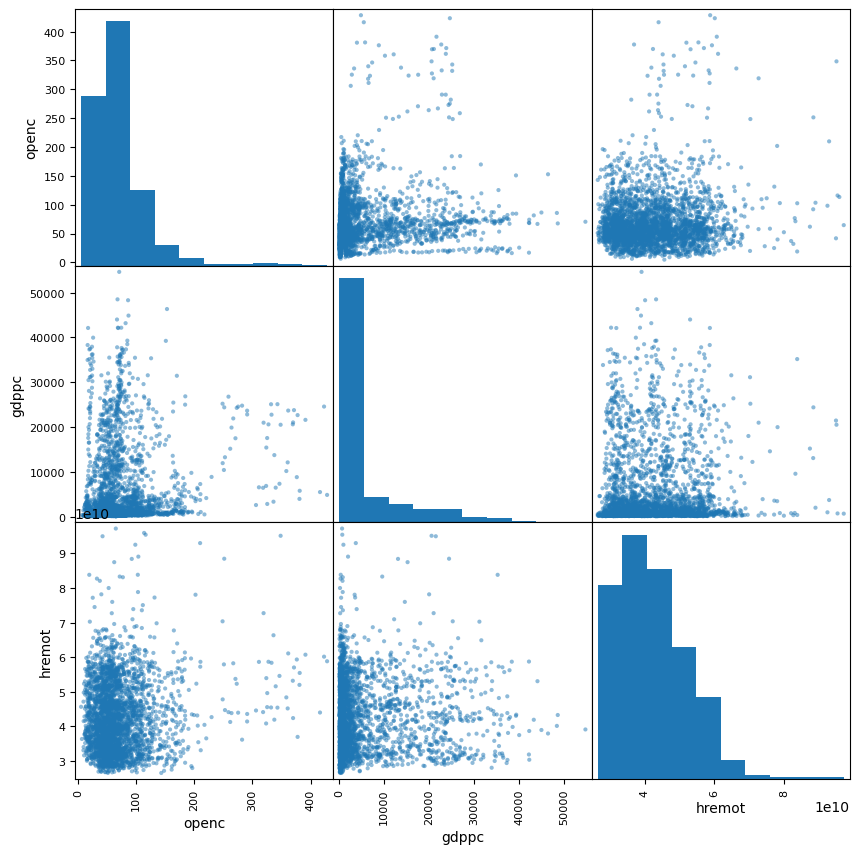

In [7]:
# 선택한 변수들의 산포도 행렬 그리기 (diagonal은 히스토그램으로 표시)
_ = pd.plotting.scatter_matrix(selected_variables, figsize=(10,10))
plt.show()

### 로그 변환

In [8]:
df['ln_gdppc'] = np.log(df['gdppc'])
df['ln_hremot'] = np.log(df['hremot'])

**상관계수**

In [9]:
# 선택한 변수들에 대한 상관계수 행렬 계산
selected_ln_variables = df[['openc', 'ln_gdppc', 'ln_hremot']]
selected_ln_variables.corr()

,openc,ln_gdppc,ln_hremot
openc,1.000000,0.240749,0.095876
ln_gdppc,0.240749,1.000000,0.068544
ln_hremot,0.095876,0.068544,1.000000


**상관계수**
- 대외개방도(`openc`)와 로그 1인당 GDP(`ln_gdppc`)는 양의 상관관계(0.241).
- 대외개방도(`openc`)와 로그 원격성(`ln_hremot`) 역시 양의 상관관계(0.096).

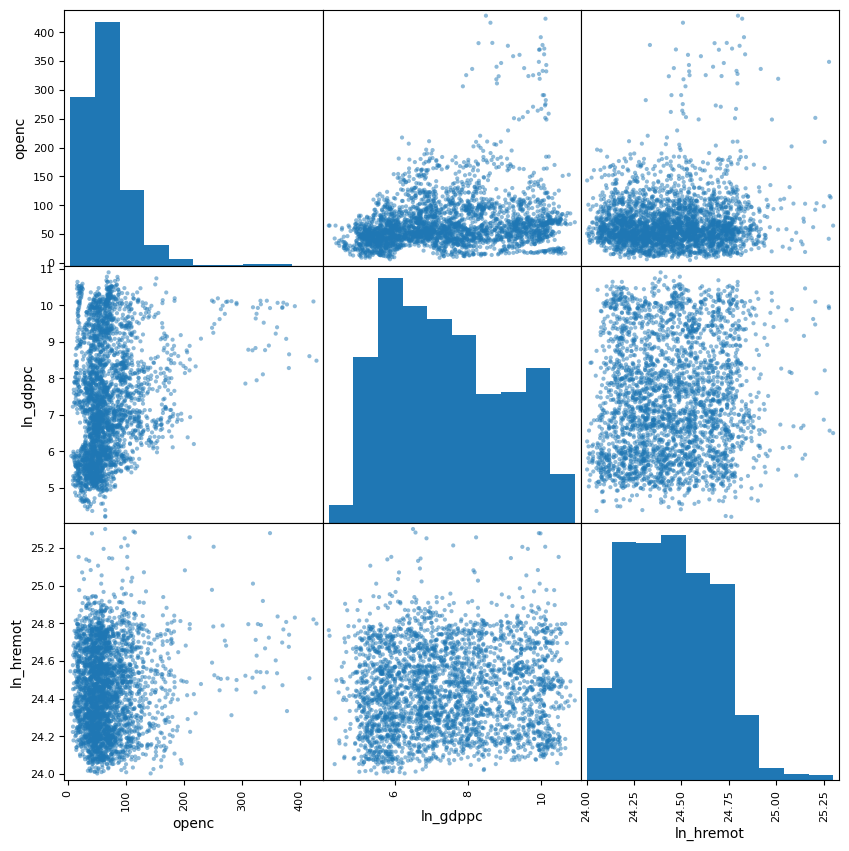

In [10]:
# 선택한 변수들의 산포도 행렬 그리기 (diagonal은 히스토그램으로 표시)
_ = pd.plotting.scatter_matrix(selected_ln_variables, figsize=(10,10))
plt.show()

### 내륙국/섬나라와 대외개방도

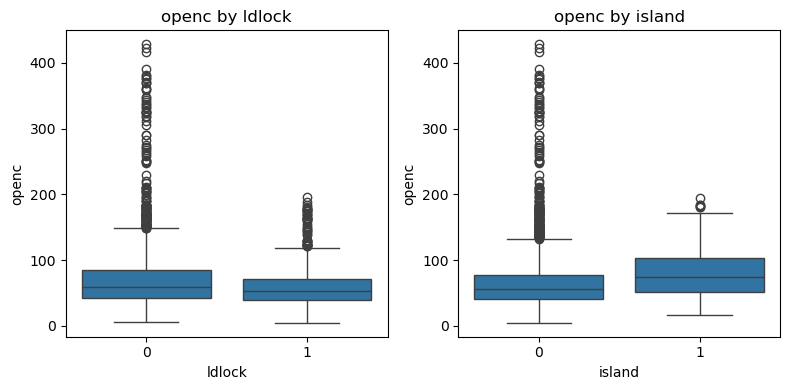

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1행 2열의 서브플롯 생성 (figsize는 필요에 따라 조정)
fig, axes = plt.subplots(1, 2, figsize=(8,4))

# ldlock에 따른 openc 상자 그림
sns.boxplot(x='ldlock', y='openc', data=df, ax=axes[0])
axes[0].set_title('openc by ldlock')
axes[0].set_xlabel('ldlock')
axes[0].set_ylabel('openc')

# island에 따른 openc 상자 그림
sns.boxplot(x='island', y='openc', data=df, ax=axes[1])
axes[1].set_title('openc by island')
axes[1].set_xlabel('island')
axes[1].set_ylabel('openc')

plt.tight_layout()
plt.show()

- 내륙국(`ldlock=1`)의 대외개방도(`openc`)가 더 낮은 경향이 있음.
- 섬나라(`island=1`)의 대외개방도(`openc`)가 더 높은 경향이 있음.

In [12]:
# ldlock에 따른 openc의 평균 계산
df.groupby('ldlock')['openc'].mean()

ldlock
0    71.158829
1    62.009691
Name: openc, dtype: float64

In [13]:
# island에 따른 openc의 평균 계산
df.groupby('island')['openc'].mean()

island
0    67.792053
1    79.769289
Name: openc, dtype: float64

### 대외개방도와 로그 1인당 GDP

**산점도 & 선형 피팅**

- 예제로 `year=2000`이고, `openc`가 200 이하인 횡단면(cross-sectional) 관측을 사용해보자.

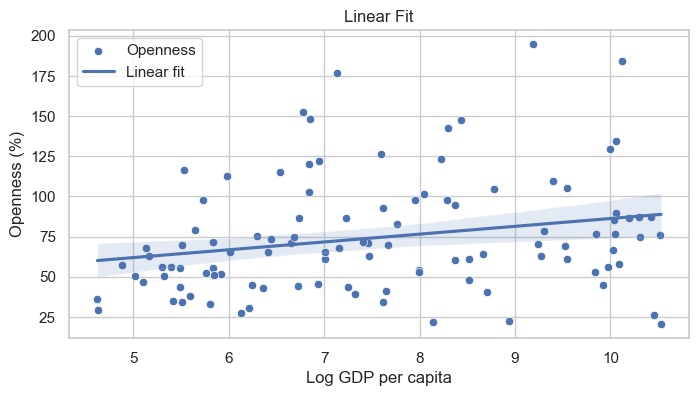

In [14]:
# 플롯: Linear fit
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,4))
filtered_df = df[(df['year'] == 2000) & (df['openc'] <= 200)]
sns.scatterplot(x='ln_gdppc', y='openc', data=filtered_df, label='Openness')
sns.regplot(x='ln_gdppc', y='openc', data=filtered_df, order=1, scatter=False, label='Linear fit')

plt.title("Linear Fit")
plt.xlabel("Log GDP per capita")
plt.ylabel("Openness (%)")
plt.legend()
plt.show()

In [15]:
model = smf.ols('openc ~ ln_gdppc', data=filtered_df).fit()
print("The R-squared of the Linear Fit:", model.rsquared)

The R-squared of the Linear Fit: 0.05476877290397408


**산점도 & 2차피팅**
- 마찬가지로 `year=2000`이고, `openc`가 200 이하인 횡단면(cross-sectional) 관측을 사용한다.

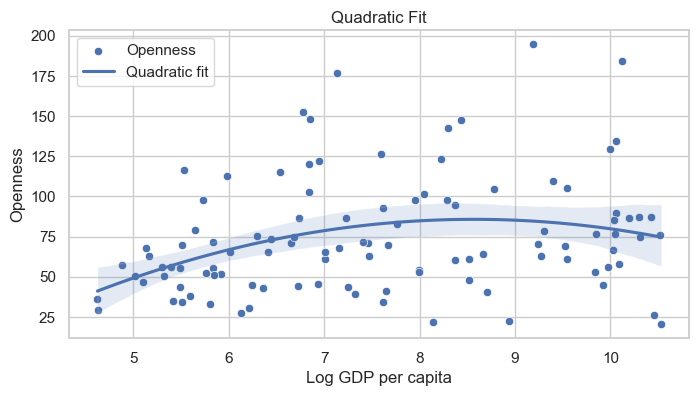

In [16]:
# 플롯: Quadratic fit
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,4))
filtered_df = df[(df['year'] == 2000) & (df['openc'] <= 200)]
sns.scatterplot(x='ln_gdppc', y='openc', data=filtered_df, label='Openness')
sns.regplot(x='ln_gdppc', y='openc', data=filtered_df, order=2, scatter=False, label='Quadratic fit')

plt.title("Quadratic Fit")
plt.xlabel("Log GDP per capita")
plt.ylabel("Openness")
plt.legend()
plt.show()

In [17]:
model = smf.ols('openc ~ ln_gdppc + np.power(ln_gdppc,2)', data=filtered_df).fit()
print("The R-squared of the Quadratic Fit:", model.rsquared)

The R-squared of the Quadratic Fit: 0.0982380948982603


## 3. 패널 회귀 분석

### 3.1 패널 데이터 분석

패널 데이터(panel data)는 여러 개체(국가, 기업, 개인 등)를 여러 시점에 걸쳐 반복적으로 관측한 데이터를 말한다. 즉, 횡단면 데이터(서로 다른 개체 간 비교)와 시계열 데이터(시간에 따른 변화)의 성격을 동시에 지닌다. 이 데이터의 장점은, **시간에 따른 변화와 개체 간 차이를 동시에 고려할 수 있다**는 점이다.

이 장의 주제를 예로 들면, 여러 나라의 대외개방도(`open`)를 여러 해에 걸쳐 관측했다면, 국가 간에는 평균적인 개방 수준의 차이가 존재하고(예: 싱가포르는 전통적으로 개방도가 높고, 내륙국은 낮음), 한 나라 안에서도 해마다 경제 여건이나 정책 변화에 따라 개방도가 달라질 수 있다. 패널 회귀모형은 이런 이중 구조를 반영해, **국가 간 차이와 시간적 변화를 동시에 분석**하도록 설계된다.

### 3.2 통합 OLS 모형(Pooled OLS Model)

통합 OLS 모형은 패널 데이터를 단순히 **하나의 큰 횡단면 표본**으로 간주한다. 즉, 국가별·시기별 고유한(unique) 차이를 고려하지 않고, 모든 관측치를 동일한 집단에서 온 것으로 본다. 식으로 표현하면 다음과 같다.

$$
openc_{it} = \alpha + \beta_1 \ln(gdppc_{it}) + \beta_2 ldlock_i + \beta_3 island_i + \beta_4 \ln(hremot_{it}) + \epsilon_{it}
$$

이 모형에서는 모든 국가가 동일한 절편($\alpha$)을 갖는다. 따라서 한국과 스위스의 제도적 차이와 같은 **국가 고유 요인**(country-specific factors)은 반영되지 않는다. 따라서 만약 설명변수(`ln_gdppc`, `ldlock`, `island`, `ln_hremot`)가 이러한 국가 특성과 상관이 있다면 추정된 계수는 편향될 수 있다.

In [18]:
pooling_results = smf.ols('openc ~ ln_gdppc + ldlock + island + ln_hremot', data=df).fit()
print(pooling_results.summary())

                            OLS Regression Results                            
Dep. Variable:                  openc   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     51.48
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           5.35e-42
Time:                        11:00:29   Log-Likelihood:                -15952.
No. Observations:                3039   AIC:                         3.191e+04
Df Residuals:                    3034   BIC:                         3.194e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -328.3899     91.487     -3.589      0.0

**추정 결과 요약**

- 위 회귀 분석 추정 결과를 보면, 1인당 GDP가 높을수록 대외개방도가 높은 경향이 있으며, 이는 통계적으로 유의하다. 

- 주요 경제권과 멀리 떨어져 있을수록 대외개방도가 높은 경향이 있으며, 이는 통계적으로 유의하다. 

- 내륙국이 비내륙국에 비해 대외개방도가 높은 경향이 있으나, 이는 통계적으로 유의하지 않다.

- 섬나라가 섬나라가 아닌 경우에 비해 대외개방도가 높은 경향이 있으나, 이는 10% 유의수준에서 통계적으로 유의하지 않다. 

### 3.3 패널 고정효과 모형

고정효과(FE: Fixed Effect) 모형은 개체별로 변하지 않는 요인을 통제하여, 개별 국가 내부의 시간적 변화가 종속변수에 어떤 영향을 미치는지를 식별한다. 즉, 각 국가는 자신만의 절편(기본 수준)을 가지며, 그 절편은 (설명변수에 포함되어 있지 않은) 그 나라의 고정된 특성(지리, 제도, 문화 등)을 대표한다. 식으로 쓰면 다음과 같다.

$$
openc_{it} = \alpha_i + \beta_1 \ln(gdppc_{it}) + \beta_2 ldlock_i + \beta_3 island_i + \beta_4 \ln(hremot_{it}) + \epsilon_{it}
$$

여기서 $\alpha_i$는 국가 $i$의 고유한 특성을 의미한다. 이 접근은 다음 두 가지 형태로 구현할 수 있다.

#### 3.3.1 더미변수를 이용한 고정효과 모형

이 모형은 선형 OLS에 **국가별 더미변수**(`C(ccode)`)를 추가하여 각 나라에 고유한 절편을 부여한다. 이 방식은 아래 결과에서 보는 것처럼, 형식상으로는 `ldlock`(내륙국 더미)와 `island`(섬나라 더미) 계수도 추정된다. 그러나 실질적으로는 국가별 더미와 `ldlock` 및 `island`가 완벽히 중복(collinear)되기 때문에, 그 계수는 식별되지 않거나, 수치적으로 불안정할 수 있다. 즉, 통계 패키지가 자동으로 제거하지 않더라도, 그 추정치는 경제적으로 의미를 갖지 못한다.

In [19]:
fe_results_dummy = smf.ols('openc ~ ln_gdppc + ldlock + island + ln_hremot + C(ccode)', data=df).fit()
print(fe_results_dummy.summary())

                            OLS Regression Results                            
Dep. Variable:                  openc   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     242.0
Date:                Thu, 11 Dec 2025   Prob (F-statistic):               0.00
Time:                        11:00:29   Log-Likelihood:                -12552.
No. Observations:                3039   AIC:                         2.532e+04
Df Residuals:                    2929   BIC:                         2.599e+04
Df Model:                         109                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           8.9872     34.395     

#### 3.3.2 `PanelOLS`를 이용한 고정효과 모형

앞 절의 모형은 패널 분석 모형으로도 추정이 가능하다. `PanelOLS`는 위의 더미 방식과 같은 원리를 보다 효율적으로 수행한다. 패널 분석 모형 추정을 위해서는 먼저 `linearmodels` 패키지를 설치해야 한다. 그런 다음, 개체(`ccode`)와 시간(`year`)을 인덱스로 설정한다. 

**`linearmodels` 패키지 설치**

In [20]:
# 처음에 한 번만 설치
# !pip install linearmodels  

In [21]:
# ccode와 year를 인덱스로 설정
df_panel = df.set_index(['ccode', 'year'])
df_panel = df_panel.dropna()
df_panel.head()

openc  openk          pop   gdp_current  ldlock  island  \
ccode year                                                            
AGO   1985  61.65  62.08  7584.709961  6.800000e+09       0       0   
      1986  48.96  53.80  7748.629883  6.360000e+09       0       0   
      1987  59.01  60.43  7878.399902  7.380000e+09       0       0   
      1988  58.75  63.70  8023.390137  7.980000e+09       0       0   
      1989  56.63  64.28  8153.839844  9.280000e+09       0       0   

             remoteness  remoteness_head        gdppc        hremot  ln_gdppc  \
ccode year                                                                      
AGO   1985  5882.432617     3.092734e+10   896.540545  3.092734e+10  6.798544   
      1986  4061.574707     5.125150e+10   820.790268  5.125150e+10  6.710268   
      1987  5953.594727     3.405364e+10   936.738436  3.405364e+10  6.842404   
      1988  4458.829102     4.117077e+10   994.592045  4.117077e+10  6.902333   
      1989  4060.890625     3.649612e+10  1138.114088  3.649612e+10  7.037128   

            ln_hremot  
ccode year             
AGO   1985  24.154907  
      1986  24.660011  
      1987  24.251204  
      1988  24.440994  
      1989  24.320473

**`PanelOLS` 함수**

패널 고정효과 모형은 `linearmodels.panel` 모듈의 `PanelOLS` 함수를 사용하면 된다. `EntityEffects` 옵션은 국가별 고정효과를 자동으로 추가하며, `drop_absorbed=True`는 국가별로 변하지 않아 식별되지 않는 변수를 자동으로 제거한다. 즉, 우리 예에서 `ldlock` 및 `island`는 시간에 따라 변하지 않는 변수이므로 고정효과와 완전히 중복되어 추정에서 제외된다. 

이 모형은 각 국가의 변하지 않는 특성을 제거하고, 시간에 따라 변하는 요인들(GDP 및 원격성의 변화 등)이 개방도에 미치는 영향을 식별한다. 결국, PanelOLS 모형의 해석은 "**개별 나라 안에서** GDP나 원격성이 변할 때, 대외개방도가 평균적으로 어떻게 변하는가?"이다. 

In [22]:
from linearmodels.panel import PanelOLS

# 고정효과 회귀모형 추정
fe_results_PanelOLS = PanelOLS.from_formula(
    'openc ~ ln_gdppc + ldlock + island + ln_hremot + EntityEffects', data=df_panel, drop_absorbed=True
).fit()

print(fe_results_PanelOLS)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  openc   R-squared:                        0.0530
Estimator:                   PanelOLS   R-squared (Between):              0.5067
No. Observations:                3039   R-squared (Within):               0.0530
Date:                Thu, Dec 11 2025   R-squared (Overall):              0.4889
Time:                        11:00:31   Log-likelihood                -1.255e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      81.933
Entities:                         108   P-value                           0.0000
Avg Obs:                       28.139   Distribution:                  F(2,2929)
Min Obs:                       15.000                                           
Max Obs:                       29.000   F-statistic (robust):             81.933
                            

C:\Users\pilsu\AppData\Local\Temp\ipykernel_29460\296132035.py:6: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

ldlock, island

  ).fit()


위 추정 결과에서 `ln_gdppc` 및 `ln_hremot`의 추정 계수(각각 8.4848 및 1.8595)가 앞 절에서 더미변수를 사용해 `smf.ols` 함수로 고정효과 모형을 추정한 결과와 동일한 것을 확인할 수 있다.

### 3.4 패널 확률효과 모형

확률효과(RE: Random Effect) 모형은 개체별 차이를 확률적(random) 요인으로 처리한다. 즉, 국가마다 고유한 효과가 존재하지만, 그것이 설명변수들과 상관이 없다고 가정한다. 식으로 쓰면 다음과 같다.

$$
openc_{it} = \alpha + \beta_1 \ln(gdppc_{it}) + \beta_2 ldlock_i + \beta_3 island_i + \beta_4 \ln(hremot_{it}) + u_i + \epsilon_{it}
$$

여기서 $u_i$는 국가의 고유효과이며, $\epsilon_{it}$는 관측별 오차항이다. 두 항은 독립이며, $u_i$가 설명변수와 무관하다고 가정한다.

이 모형에서는 시간불변 변수($ldlock_i$ 및 $island_i$)도 포함될 수 있으며, 따라서 고정효과보다 더 많은 변수를 추정할 수 있다. 다만, 만약 $u_i$가 설명변수(예: $\ln(gdppc_{it})$)와 상관되어 있다면 RE 추정치는 편향될 수 있다. 이때는 **Hausman 검정**을 이용해 FE와 RE 중 어느 모형이 더 적합한지 판단한다.

In [23]:
from linearmodels.panel import RandomEffects

# 패널 확률효과 회귀모형 추정
re_results = RandomEffects.from_formula(
    'openc ~ ln_gdppc + ldlock + island + ln_hremot + EntityEffects', data=df_panel
).fit()

print(re_results.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:                  openc   R-squared:                        0.1263
Estimator:              RandomEffects   R-squared (Between):              0.7257
No. Observations:                3039   R-squared (Within):               0.0526
Date:                Thu, Dec 11 2025   R-squared (Overall):              0.6997
Time:                        11:00:31   Log-likelihood                -1.261e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      109.69
Entities:                         108   P-value                           0.0000
Avg Obs:                       28.139   Distribution:                  F(4,3035)
Min Obs:                       15.000                                           
Max Obs:                       29.000   F-statistic (robust):             109.69
                            

### 3.5 비교 요약

| 구분            | 개념                    | 개체 효과 처리 방식   | 시간불변 변수 포함 가능성     | 주요 가정             | 해석 초점         |
| ------------- | --------------------- | ------------- | ------------------ | ----------------- | ------------- |
| **통합 OLS**    | 패널 구조 무시, 모든 국가 동일 취급 | 없음            | 가능                 | 국가 간 차이 무시        | 전체 평균 관계      |
| **고정효과 (FE)** | 국가별 고정요인 통제           | 각 국가 고유 절편 허용 | 불가능 (`ldlock` 제거됨) | 개체 효과와 설명변수 상관 있음 | 국가 내부의 시간적 변화 |
| **확률효과 (RE)** | 국가 고유요인을 확률로 간주       | 분산구조로 반영      | 가능                 | 개체 효과와 설명변수 독립    | 전체적 평균 관계     |

요약하면,

* **OLS**는 모든 국가를 하나의 집단으로 보고 단순 평균 관계를 추정한다.
* **FE**는 국가 간 고정된 차이를 제거하고, 개별 국가 내에서의 변화에 집중한다. 이때 시간불변 변수는 추정되지 않는다. 
* **RE**는 국가별 고유 효과를 확률변수로 처리하여, 시간불변 변수도 포함시키되, 설명변수와 고유효과가 독립이라는 가정 하에 보다 효율적으로 추정한다.

## 4. 시간효과 추가

패널 데이터는 시간($t$)과 개체($i$)라는 두 축을 동시에 갖는다. 이때, 어떤 특정한 연도에는 모든 개체에 공통으로 작용하는 요인이 존재할 수 있다. 예를 들어, 전 세계 금융위기(2008년), 팬데믹(2020년) 등은 모든 나라의 무역과 GDP에 영향을 준다. 또 다른 예로 기술 혁신, 국제유가, 글로벌 경기 흐름도 국가를 막론하고 공통된 영향을 미칠 수 있다.

이런 연도별 공통 요인을 모형에 반영하지 않으면, 그 영향을 설명변수(예: `ln_gdppc`)가 대신 설명하려 하므로 계수가 왜곡될 수 있다. 따라서 “연도별 더미” 혹은 “시간 고정효과”를 추가해 이런 시기별 공통 충격을 통제하는 것이 중요하다.

### 4.1 고정효과 모형

고정효과(FE) 모형은 이미 **국가별 불변요인(지리, 제도 등)**을 제거한다. 여기에 `TimeEffects`를 추가하면, 이제 “모든 국가에 공통으로 작용하는 연도별 요인”도 함께 제거하게 된다. 즉, 두 종류의 고정효과가 들어가는 셈이다.

| 효과              | 통제 대상      | 의미              |
| --------------- | ---------- | --------------- |
| `EntityEffects` | 국가 간 불변 차이 | 국가지리, 제도, 문화 등  |
| `TimeEffects`   | 연도별 공통 충격  | 세계경기, 무역환경 변화 등 |

예를 들어, 2015년에 전 세계적으로 원유가격이 폭락하여 모든 나라의 무역비용이 줄었다면, 그 해의 개방도 상승분은 `TimeEffects`가 흡수한다. 따라서 FE+TimeEffects 모형의 계수는 “같은 시기 내에서, 한 나라의 GDP나 원격성이 변화할 때 그 나라의 개방도가 얼마나 변하는가?”를 보여준다. 즉, 이 모형은 **한 나라 내부에서, 그리고 특정 시기 내에서의 상대적 변화**에 집중한다.

In [24]:
from linearmodels.panel import RandomEffects

fe_results_PanelOLS = PanelOLS.from_formula(
    'openc ~ ln_gdppc + ln_hremot + EntityEffects + TimeEffects', data=df_panel, drop_absorbed=True
).fit()

print(fe_results_PanelOLS.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  openc   R-squared:                        0.0014
Estimator:                   PanelOLS   R-squared (Between):             -0.8043
No. Observations:                3039   R-squared (Within):               0.0075
Date:                Thu, Dec 11 2025   R-squared (Overall):             -0.7645
Time:                        11:00:31   Log-likelihood                -1.233e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      2.0844
Entities:                         108   P-value                           0.1246
Avg Obs:                       28.139   Distribution:                  F(2,2901)
Min Obs:                       15.000                                           
Max Obs:                       29.000   F-statistic (robust):             2.0844
                            

### 4.2 확률효과 모형

확률효과(RE) 모형에서도 `TimeEffects`를 포함하면 FE 모형과 마찬가지로 연도별 공통 충격을 제거할 수 있다. RE는 국가의 고유효과를 확률항으로 처리하기 때문에, 시간불변 변수(`ldlock`)도 여전히 추정 가능하다. 즉, `TimeEffects`는 “모든 나라에 동시에 영향을 미친” 연도별 요인을 통제하고, RE 구조는 “국가마다 다른 평균 수준”을 확률적으로 보정한다. 따라서 RE+TimeEffects 모형의 계수는 “같은 연도에 속한 여러 나라들 사이에서, GDP나 원격성이 다른 나라보다 얼마나 높은 개방도와 관련되는가”를 의미한다.

In [25]:
from linearmodels.panel import RandomEffects

re_results = RandomEffects.from_formula(
    'openc ~ ln_gdppc + ldlock + island + ln_hremot + EntityEffects + TimeEffects', data=df_panel, 
).fit()

print(re_results.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:                  openc   R-squared:                        0.1263
Estimator:              RandomEffects   R-squared (Between):              0.7257
No. Observations:                3039   R-squared (Within):               0.0526
Date:                Thu, Dec 11 2025   R-squared (Overall):              0.6997
Time:                        11:00:31   Log-likelihood                -1.261e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      109.69
Entities:                         108   P-value                           0.0000
Avg Obs:                       28.139   Distribution:                  F(4,3035)
Min Obs:                       15.000                                           
Max Obs:                       29.000   F-statistic (robust):             109.69
                            

### 4.3 요약 비교

| 모형                   | 시간효과 추가 방법     | 의미                        | 효과                         |
| -------------------- | -------------- | ------------------------- | -------------------------- |
| **FE + TimeEffects** | 국가 + 연도 고정효과   | 국가 고유요인과 연도별 공통요인 모두 통제   | “같은 해 안에서, 한 나라의 변화 효과” 식별 |
| **RE + TimeEffects** | 확률효과 + 연도 고정효과 | 국가 간 무작위 차이와 연도별 공통 충격 통제 | “같은 연도 내 국가 간 평균적 관계” 식별   |

간단히 요약하자면 `+ C(year)`나 `+ TimeEffects`를 추가하면 **연도별로 전 세계에 공통된 영향을 제거**하게 된다. 즉, “2008년엔 세계 전체가 나빴다” 같은 공통 시기 효과를 모형이 알아서 흡수한다. 그 결과, 나머지 변수의 계수는 “같은 시기 안에서, 어떤 나라(또는 개체)의 상대적 변화나 수준 차이”를 보여준다.

# 부록: 패널 데이터 분석

패널 데이터(panel data)는 동일한 개체(individual)에 대해 여러 시점(time period)에 걸쳐 관측한 자료이다. 이러한 자료를 활용하면 개체별로 눈에 보이지 않는(unobserved) 고유한 이질성(heterogeneity)을 통제할 수 있다. 이는 횡단면(cross-section) 자료나 시계열(time series) 자료만으로는 얻기 어려운 장점이다. 

## A1. 패널 데이터의 특성

패널 데이터는 개체별 특성과 시간적 변화를 동시에 고려할 수 있는 데이터 구조를 갖는다. 예를 들어, 도시별 범죄율을 분석한다고 하자. 도시의 범죄율에 대한 참 모형을 다음과 같이 가정해보자.

$$
crime_{it} = -0.1 \times police_{it} + 10 \times character_i + \epsilon_{it}
$$

- $crime_{it}$: 도시 $i$의 $t$시점 범죄율  
- $police_{it}$: 도시 $i$의 $t$시점 경찰관 수  
- $character_i$: 도시 $i$의 고유한 범죄환경(시간 불변)  
- $\epsilon_{it}$: 오차항  

우리는 여기에서 **도시 $i$의 고유한 범죄환경을 나타내는 $character_i$ 변수는 눈에 보이지 않을 뿐만 아니라 시간에 따라 변하지 않는다고 가정**한다. 이와 같은 상황에서 가령 다음과 같은 특징을 지닌 두 도시가 있다고 하자.

- 도시 1: 범죄환경이 매우 양호 → $character_1 = 1$  
- 도시 2: 범죄환경이 매우 나쁨 → $character_2 = 5$

현실적으로 범죄환경이 나쁜 2번 도시에는 경찰관이 상대적으로 더 많을 가능성이 높다. 따라서 우리는 **범죄환경과 경찰관 수 사이에는 양의 상관관계가 있다고 가정**한다. 즉, 어떤 시점 $t$에 $\text{Cov}(police_{it}, character_i) > 0$이 성립한다고 가정한다. 범죄환경이 나쁠수록(즉, $character_i$ 값이 클수록) 해당 도시에 경찰관이 더 많다는 것을 의미한다. 이상의 가정을 충족하는 다음의 예시 데이터를 생각해보자.

<div style="text-align: center;">
<b>예시 데이터</b>  (오차항은 0으로 가정함.)
</div>

<div style="text-align: center;">
  <img src="https://raw.githubusercontent.com/pilsunchoi/images2/main/1.png" alt="image" width="450"/>
</div>

### 횡단면 데이터의 한계

우리에게 주어진 것이 패널 데이터가 아니라 횡단면 데이터로서 가령 2020년의 단일 시점 데이터만 존재한다고 해보자. $character_i$ 변수는 **관측불가능**하기 때문에 우리에게 주어진 **관측가능**한 데이터는 다음과 같다. 

<div style="text-align: center;">
  <img src="https://raw.githubusercontent.com/pilsunchoi/images2/main/2.png" alt="image" width="350"/>
</div>
<br></br>

이 경우, 주어진 횡단면 데이터로부터 추정되는 경찰관 수와 범죄율의 관계는 아래와 같은 형태이며, 이는 실제 관계를 완전히 호도하는 결과이다. 참 모형에서는 다른 조건을 통제한 상태에서 경찰 1명이 늘어나면 범죄율이 0.1만큼 줄어드나, 아래 그림에서는 경찰이 늘어날수록 오히려 범죄율이 높아진다. 주어진 참 모형에서 발생시킨 데이터를 이용하여 추정했는데도 이처럼 실제를 정반대로 묘사하는 결과를 얻게 된 이유는 각 도시의 고유한 범죄환경인 $character_i$ 변수가 관측되지 않고 빠져있기 때문이다.

<br></br>
<div style="text-align: center;">
  <img src="https://raw.githubusercontent.com/pilsunchoi/images2/main/3.png" alt="image" width="450"/>
</div>

## A2. 통합 횡단면 추정

패널 데이터를 시간과 개체 상관없이 횡단면 데이터로 간주하고 추정하는 것을 통합 횡단면(pooled cross-sectional) 모형이라 한다. 이 경우에도 위의 단일 횡단면 분석과 마찬가지로 여전히 편의가 발생할 가능성이 있다. 우리 예에서는 추정 결과가 다음과 같은데, 여전히 경찰관 숫자가 늘어날수록 범죄율이 높아지는 것으로 나오는 것을 알 수 있다.($police$  추정계수 0.69)

<div style="text-align: center;">
  <img src="https://raw.githubusercontent.com/pilsunchoi/images2/main/4.png" alt="image" width="450"/>
</div>


## A3. 고정효과 모형

앞에서는 횡단면 데이터만 있거나, 아니면 패널 데이터가 있는데도 그것을 하나의 통합된 횡단면 데이터로 취급하는 것을 다루었으며, 이럴 경우 편의가 발생할 수 있다는 것을 살펴보았다. 

하지만 패널 데이터가 있다면 $character_i$ 변수와 같은 개체별 고유한 이질성, 혹은 고정된 효과(fixed effect)를 포착하는 것이 가능하다.

<div style="text-align: center;">
  <img src="https://raw.githubusercontent.com/pilsunchoi/images2/main/5.png" alt="image" width="450"/>
</div>

<br></br>

여기에서 $character_i$ 변수를 관측할 수는 없지만 더미변수나 차분 등의 방법으로 포착 가능하다. 이를 **고정효과**(FE: Fixed Effect) 모형이라 부른다.

(1) **더미변수 이용:** 개체마다 고유한 더미변수를 포함하여 추정.($police$  추정계수 -0.1)

<div style="text-align: center;">
  <img src="https://raw.githubusercontent.com/pilsunchoi/images2/main/6.png" alt="image" width="450"/>
</div>

(2) **차분(혹은 With-in) 변환:** 개체 평균을 제거하여 개체의 고정된 특성을 없애는 방식.($police$  추정계수 -0.1)

<div style="text-align: center;">
  <img src="https://raw.githubusercontent.com/pilsunchoi/images2/main/7.png" alt="image" width="450"/>
</div>
<div style="text-align: center;">
  <img src="https://raw.githubusercontent.com/pilsunchoi/images2/main/8.png" alt="image" width="450"/>
</div>

더미변수 방식과 With-in 변환은 수학적으로 동일하다. 이들은 개체의 불변 특성을 제거하여 설명변수와 오차항의 상관 문제를 해결한다. 

### 고정효과 모형의 장단점

- 장점: 고정효과 모형에 의한 추정은 관측불가능한 고유한 이질성을 포착함으로써 추정계수의 정확도를 높일 수 있다. 달리 표현하면, 계수 추정치의 일치성(consistency)을 보장한다.

- 단점: 더미변수든, With-in 변환이든 계수 추정의 효율성(efficiency)이 떨어진다. 즉, 추정계수의 표준오차가 커진다. 더미변수 추정의 경우 더미변수 개수만큼 변수의 숫자가 많아지고, With-in 변환의 경우 개체 숫자만큼 관측 숫자가 줄어들기 때문이다. 개체는 많고, 시간이 짧은 패널 데이터인 경우, 이 문제가 심각해질 수 있다.

## A4. 확률효과 모형

### 내생성 문제와 편향

앞에서 패널 데이터를 통합 횡단면 모형으로 추정하면 편향이 발생할 가능성이 있다고 했는데, 이는 개체별 이질성이 설명변수와 상관성을 지니고 있을 때이다. 우리 예에서는 범죄환경이 높은 도시일수록 경찰관 숫자가 많은 것이 여기에 해당한다. 즉 $Cov(police_{it}, \epsilon_{it}) > 0$인 경우 통합 횡단면 모형으로 추정하면 편향이 발생한다. $Cov(x_i, \epsilon_i) \neq 0$을 **내생성**(endogeneity) 문제라 부른다.

하지만 개체별 이질성과 설명변수가 상관성이 없는 경우에는 편향을 걱정할 필요가 없다. 예를 들어 다음과 같이 $Cov(police_{it}, \epsilon_{it}) = 0$인 경우에는 내생성 문제가 발생하지 않는다.

<div style="text-align: center;">
  <img src="https://raw.githubusercontent.com/pilsunchoi/images2/main/9.png" alt="image" width="450"/>
</div>

<br></br>

이 경우에는 아래와 같이 그냥 통합 횡단면 모형으로 추정해도 올바른 계수 추정치를 얻을 수 있다.

<div style="text-align: center;">
  <img src="https://raw.githubusercontent.com/pilsunchoi/images2/main/10.png" alt="image" width="450"/>
</div>

### 확률효과 추정

**확률효과**(RE: Random Effect) 모형은 기본적으로 개체별 이질성이 무작위(random)여서 설명변수와 상관성이 없다고 보는 모형이다. 이럴 경우 앞의 예에서 보았듯이 이 모형을 통합 횡단면으로 추정해도 편향은 발생하지 않지만, 그것과는 별개로 오차항($\epsilon_{it}$)의 자기상관성(autocorrelation) 문제가 발생하기 때문에 이를 고려하여 OLS가 아니라 **GLS**(Generalized Least Squares: 일반최소제곱) 방법으로 추정한다.

## A5. 요약 및 Hausman 검정

다음과 같은 패널 모형을 생각해보자.

$$
y_{it} = \alpha + \beta_1 x_{it} + u_i + \epsilon_{it}
$$

이는 다음과 같이 다시 쓸 수 있다.

$$
y_{it} = \alpha + \beta_1 x_{it} + w_{it}, \quad (\text{여기서  }  w_{it} = u_i + \epsilon_{it})
$$

여기에서 $u_i$가 $x_{it}$와 상관성이 있을 때, 즉 $x_{it}$가 오차항 $w_{it}$와 상관성이 있을 때는 내생성 문제가 발생하며, 이 상황에서 편향이 없는 추정(consistent 추정)을 위해서는 **고정효과 모형**으로 추정해야 한다. 즉, 더미변수를 사용하거나, within 변환을 이용해 추정한다. 하지만 고정효과 모형은 (i) 효율성(efficiency)에 손실이 있으며(이는 표준오차를 높임), (ii) 시간불변 설명변수의 추정이 불가능하다는 문제를 가진다.

만약 $u_i$를 확률적인(random) 것으로 간주할 수 있으면, $u_i$가 $x_{it}$와 상관성이 없다. 즉, $x_{it}$가 오차항 $w_{it}$와 상관성이 없다. 따라서 내생성 문제가 발생하지 않기 때문에 편향 문제를 걱정할 필요가 없다. 이 경우, 오차항의 자기상관 문제를 해결하기 위해 GLS 방법으로 추정하게 되며, 이것이 **확률효과 모형**이다. 이는 고정효과 모형에 비해 더 효율적(efficient)이다. 즉, 추정계수의 표준오차가 더 작다.

### Hausman 검정

Hausman Test는 고정효과(FE) 모형과 확률효과(RE) 모형의 추정치 차이를 검정한다.

- $\hat{\beta}_{FE}$와 $\hat{\beta}_{RE}$의 차이가 클수록(그리고 $\text{se}(\hat{\beta}_{FE}) - \text{se}(\hat{\beta}_{RE})$의 차이가 작을수록)  
  $\Rightarrow$ FE 모형과 RE 모형 간 차이가 없다는 귀무가설을 기각하고, 편향이 발생하지 않는, 즉 일치적(consistent) 추정이 가능한 고정효과 모형을 권장하게 된다.

- 반대로 $\hat{\beta}_{FE}$와 $\hat{\beta}_{RE}$의 차이가 없을수록(그리고 $\text{se}(\hat{\beta}_{FE}) - \text{se}(\hat{\beta}_{RE})$의 차이가 클수록)  
  $\Rightarrow$ FE 모형과 RE 모형 간 차이가 없다는 귀무가설을 기각하지 못하기 때문에, 표준오차가 더 작은, 즉 효율적(efficient) 추정이 가능한 확률효과 모형을 권장하게 된다.


## A6. 분석 예제를 통한 이해

### 예제 1: 경찰관 숫자가 범죄율에 미치는 영향

도시별 '인구 1,000명 당 경찰관 수'가 '범죄율'에 어떤 영향을 미치는지 분석하고자 한다. 정확한 인과관계 파악을 위해서는 범죄율에 영향을 주는 다른 요인들을 철저히 통제해야 한다.

여기서 한 가지 문제가 발생한다. 각 도시는 관측하기 힘든 고유한 특성(이질성), 예를 들어 시민들의 법 준수 의식이나 지역의 고유한 범죄 문화 등을 가지고 있다. 만약 범죄 문화가 만연한 도시일수록(관측 불가능한 요인) 이에 대응하기 위해 경찰관을 더 많이 채용한다면(설명변수), 이 두 변수는 서로 상관성(correlation)을 갖게 된다.

이 경우, 일반적인 회귀분석을 하면 도시별 이질성을 통제하지 못해 경찰관 수가 범죄율에 미치는 순수한 효과를 왜곡(편향)되게 추정할 위험이 있다.

이때 패널 데이터를 활용하면 해결책을 찾을 수 있다.

* **고정효과 모형:** 도시별로 변하지 않는 고유한 특성이 있다고 가정하고, 이를 모형에서 제거하거나 통제한다. 직관적으로는 각 도시를 나타내는 더미변수를 추가하여 추정하는 것과 같다. 이를 통해 도시 고유의 특성이 경찰관 수와 상관관계가 있더라도 편향 없는 결과를 얻을 수 있다.

* **확률효과 모형:** 만약 도시의 고유한 특성이 경찰관 수와 전혀 상관관계가 없다고 가정할 수 있다면, 굳이 고정효과를 쓸 필요가 없다. 이 경우 고정효과 모형보다 정보의 손실이 적어 통계적으로 더 효율적인(efficient) 확률효과 모형을 사용한다. 이는 전체 데이터를 합쳐서 분석하는 풀링(pooling) OLS와 가정은 유사하지만, 오차항의 구조를 고려한 추정법(GLS)을 사용하여 추정량의 신뢰성을 더 높인 방식이다.

### 예제 2: 과외시간이 학업성적에 미치는 영향

학생별로 '과외공부시간'이 '학업성적'에 어떤 영향을 미치는지 분석하고자 한다. 물론 학업성적에 영향을 미치는 여러가지 요인을 통제하여 과외시간의 순수한 효과를 파악하는 것이 가장 먼저 해야할 일이다.

그런데 만약 학생별로 어떤 독특한 요인(이질성)이 학업성적에 중요하게 영향을 미치고(가령 타고난 지능이나 성실성), 이것이 우리가 그 효과를 분석하려는 과외시간과 상관관계를 지니고 있다고 해보자. 이 경우 추정 모형이 학생별 이질성을 통제할 수 없기 때문에 공부시간이 학업성적에 미치는 효과 추정에 편향이 발생할 수 있다.

이와 같은 상황에서 패널 데이터가 있다면 학생별 관측불가능한 고정 요인을 통제할 수 있다.

* **고정효과 모형:** 학생별로 변하지 않는 고유한 특성이 있다고 가정하고, 이를 모형에서 제거하거나 통제한다. 직관적으로는 각 학생을 나타내는 더미변수를 추가하여 추정하는 것과 같다. 이를 통해 학생 고유의 특성이 과외시간과 상관관계가 있더라도 편향 없는 결과를 얻을 수 있다.

* **확률효과 모형:** 만약 학생의 고유한 특성이 과외시간과 전혀 상관관계가 없다고 가정할 수 있다면, 굳이 고정효과를 쓸 필요가 없다. 이 경우 고정효과 모형보다 정보의 손실이 적어 통계적으로 더 효율적인(efficient) 확률효과 모형을 사용해 추정해도 된다. 이는 사실상 패널 데이터를 pooling하여 횡단면 데이터처럼 취급하는 것과 유사하지만, 오차항의 구조를 고려한 추정법(GLS)을 사용하여 추정량의 신뢰성을 더 높인 방식이다.

### 예제 3: 학교별 다문화학생 비율이 학업성적에 미치는 영향

학교별로 '다문화학생 비율'이 '학업성적'에 어떤 영향을 미치는지 분석하고자 한다. 물론 학업성적에 영향을 미치는 여러가지 요인을 통제하여 다문화학생 비율의 순수한 효과를 파악하는 것이 가장 먼저 해야할 일이다.

그런데 만약 학교별로 어떤 독특한 요인(이질성)이 학업성적에 중요하게 영향을 미치고(가령 지역의 소득수준이나 교육열), 이것이 우리가 그 효과를 분석하려는 다문화학생 비율과 상관관계를 지니고 있다고 해보자. 이 경우 추정 모형이 학교별 이질성을 통제할 수 없기 때문에 다문화학생 비율이 학업성적에 미치는 효과 추정에 편향이 발생할 수 있다.

이와 같은 상황에서 패널 데이터가 있다면 학교별 관측불가능한 고정 요인을 통제할 수 있다.

* **고정효과 모형:** 학교별로 변하지 않는 고유한 특성이 있다고 가정하고, 이를 모형에서 제거하거나 통제한다. 직관적으로는 각 학교를 나타내는 더미변수를 추가하여 추정하는 것과 같다. 이를 통해 학교 고유의 특성이 다문화학생 비율과 상관관계가 있더라도 편향 없는 결과를 얻을 수 있다.

* **확률효과 모형:** 만약 학교의 고유한 특성이 다문화학생 비율과 전혀 상관관계가 없다고 가정할 수 있다면, 굳이 고정효과를 쓸 필요가 없다. 이 경우 고정효과 모형보다 정보의 손실이 적어 통계적으로 더 효율적인(efficient) 확률효과 모형을 사용해 추정해도 된다. 이는 사실상 패널 데이터를 pooling하여 횡단면 데이터처럼 취급하는 것과 유사하지만, 오차항의 구조를 고려한 추정법(GLS)을 사용하여 추정량의 신뢰성을 더 높인 방식이다.

### 예제 4: 학생별 이주배경 여부가 학업성적에 미치는 영향

학생별로 '이주배경 여부(또는 다문화 가정 여부)'가 '학업성적'에 어떤 영향을 미치는지 분석하고자 한다. 물론 학업성적에 영향을 미치는 여러가지 요인을 통제하여 이주배경의 순수한 효과를 파악하는 것이 가장 먼저 해야할 일이다.

그런데 만약 학생별로 어떤 독특한 요인(이질성)이 학업성적에 중요하게 영향을 미치고(가령 타고난 지능이나 학습 동기), 이것이 우리가 그 효과를 분석하려는 이주배경 여부와 상관관계를 지니고 있다고 해보자. 이 경우 추정 모형이 학생별 이질성을 통제할 수 없기 때문에 이주배경이 학업성적에 미치는 효과 추정에 편향이 발생할 수 있다.

이와 같은 상황에서 패널 데이터가 있다면 학생별 관측불가능한 고정 요인을 통제할 수 있다.

* **고정효과 모형:** 학생별로 변하지 않는 고유한 특성이 있다고 가정하고, 이를 모형에서 제거하거나 통제한다. 직관적으로는 각 학생을 나타내는 더미변수를 추가하여 추정하는 것과 같다. 이를 통해 학생 고유의 특성이 이주배경 여부와 상관관계가 있더라도 편향 없는 결과를 얻을 수 있다.

* **확률효과 모형:** 만약 학생의 고유한 특성이 이주배경 여부와 전혀 상관관계가 없다고 가정할 수 있다면, 굳이 고정효과를 쓸 필요가 없다. 이 경우 고정효과 모형보다 정보의 손실이 적어 통계적으로 더 효율적인(efficient) 확률효과 모형을 사용해 추정해도 된다. 이는 사실상 패널 데이터를 pooling하여 횡단면 데이터처럼 취급하는 것과 유사하지만, 오차항의 구조를 고려한 추정법(GLS)을 사용하여 추정량의 신뢰성을 더 높인 방식이다.

---

**참고: Gemini 3.0 응답 내용 (2025년 12월)** 

제시된 구조와 논리를 그대로 적용하여 작성한 [예제 4]에 대한 설명이다. 다만, **이 예제에는 통계적으로 매우 중요한 주의사항(변수의 시간 불변성)** 이 있어, 별도의 [**핵심 검토사항**]을 추가해 두었으니 반드시 확인하기 바란다.

**⚠️ 핵심 검토사항 (매우 중요)**

위 설명은 [예제 1, 2, 3]과 논리적 구조를 맞춘 것이지만, **[예제 4]의 변수 특성상 고정효과 모형 적용에는 치명적인 제약**이 따른다.

1.  **시간 불변 변수의 문제:** '이주배경 여부'는 시간이 흐른다고 해서 변하는 것이 아니다(time-invariant). 한 번 정해지면 계속 고정되는 속성이다.
2.  **고정효과 모형의 한계:** 고정효과 모형은 '개별 특성(고정효과)'을 제거하는 과정에서, **시간에 따라 변하지 않는 설명변수들도 함께 제거**해 버린다.
3.  **결론:** 따라서 통상적인 고정효과 모형을 쓰면 우리가 알고 싶은 '이주배경' 변수의 계수 자체가 산출되지 않고 삭제(omitted)된다.
    * 이 경우, 불가피하게 **확률효과 모형**을 쓰거나,
    * 내생성 문제가 우려된다면 **하우스만-테일러(Hausman-Taylor) 모형** 등 보다 심화된 추정법을 사용해야 한다.

### 예제 5: 자유무역협정(FTA) 체결이 교역에 미치는 영향

국가 쌍(pair)별로 '자유무역협정(FTA) 체결 여부'가 '교역량'에 어떤 영향을 미치는지 분석하고자 한다. 물론 교역량에 영향을 미치는 여러가지 요인을 통제하여 FTA의 순수한 효과를 파악하는 것이 가장 먼저 해야할 일이다.

그런데 만약 국가 쌍별로 어떤 독특한 요인(이질성)이 교역량에 중요하게 영향을 미치고(가령 역사적·문화적 유대감이나 지리적 인접성), 이것이 우리가 그 효과를 분석하려는 FTA 체결 여부와 상관관계를 지니고 있다고 해보자. 이 경우 추정 모형이 국가 쌍별 이질성을 통제할 수 없기 때문에 FTA가 교역량에 미치는 효과 추정에 편향이 발생할 수 있다.

이와 같은 상황에서 패널 데이터가 있다면 국가 쌍별 관측불가능한 고정 요인을 통제할 수 있다.

* **고정효과 모형:** 국가 쌍별로 변하지 않는 고유한 특성이 있다고 가정하고, 이를 모형에서 제거하거나 통제한다. 직관적으로는 각 국가 쌍을 나타내는 더미변수를 추가하여 추정하는 것과 같다. 이를 통해 국가 간 고유의 특성이 FTA 체결 여부와 상관관계가 있더라도 편향 없는 결과를 얻을 수 있다.

* **확률효과 모형:** 만약 국가 쌍의 고유한 특성이 FTA 체결 여부와 전혀 상관관계가 없다고 가정할 수 있다면, 굳이 고정효과를 쓸 필요가 없다. 이 경우 고정효과 모형보다 정보의 손실이 적어 통계적으로 더 효율적인(efficient) 확률효과 모형을 사용해 추정해도 된다. 이는 사실상 패널 데이터를 pooling하여 횡단면 데이터처럼 취급하는 것과 유사하지만, 오차항의 구조를 고려한 추정법(GLS)을 사용하여 추정량의 신뢰성을 더 높인 방식이다.

### 예제 6: 내륙국 여부가 대외개방도에 미치는 영향

국가별로 '내륙국 여부(지리적 위치)'가 '대외개방도'에 어떤 영향을 미치는지 분석하고자 한다. 물론 대외개방도에 영향을 미치는 여러가지 요인을 통제하여 내륙국 여부의 순수한 효과를 파악하는 것이 가장 먼저 해야할 일이다.

그런데 만약 국가별로 어떤 독특한 요인(이질성)이 대외개방도에 중요하게 영향을 미치고(가령 역사적 배경이나 제도의 질), 이것이 우리가 그 효과를 분석하려는 내륙국 여부와 상관관계를 지니고 있다고 해보자. 이 경우 추정 모형이 국가별 이질성을 통제할 수 없기 때문에 내륙국 위치가 대외개방도에 미치는 효과 추정에 편향이 발생할 수 있다.

이와 같은 상황에서 패널 데이터가 있다면 국가별 관측불가능한 고정 요인을 통제하는 방법을 고려할 수 있으나, 이 사례에서는 결정적인 제약이 따른다.

* **고정효과 모형:** 국가별로 변하지 않는 고유한 특성을 통제하기 위해 각 국가의 더미변수를 추가하거나 평균 차분(demeaning)을 수행한다. 그러나 '내륙국 여부'는 시간이 흘러도 변하지 않는 **시간 불변(time-invariant) 변수**다. 고정효과 모형은 개별 특성을 제거하는 과정에서 시간 불변 변수들도 함께 제거해 버리기 때문에, 결과적으로 **내륙국 여부가 대외개방도에 미치는 영향 자체를 추정할 수 없다.** 즉, 이 변수의 계수값이 산출되지 않고 탈락한다.

* **확률효과 모형:** 따라서 이 경우 분석을 위해서는 확률효과 모형을 사용해야 한다. 확률효과 모형은 시간 불변 변수도 추정이 가능하기 때문이다. 단, 이를 위해서는 국가의 고유한 특성(오차항)이 내륙국 여부와 상관관계가 없다는 강력한 가정이 필요하다. 만약 상관관계가 의심된다면 하우스만-테일러(Hausman-Taylor) 모형 등 보다 심화된 추정법을 고려해야 한다.